In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/DoorDash.csv")

# Inspect the first few rows
print(df.head())

   recency  frequency  monetary   device  age  response  profit
0       42          8    70.872      iOS   38         0     0.0
1      119          7   103.744      iOS   22         0     0.0
2       86          8   118.752      iOS   20         0     0.0
3       84          7   139.008  Android   18         0     0.0
4       53          9    95.640  Android   23         0     0.0


In [ ]:
# Question 1

# Average response rate
response_rate = df["response"].mean()

# Average profit among responders only
avg_profit_responders = df.loc[df["response"] == 1, "profit"].mean()

print(f"Average response rate: {response_rate:.4f} ({response_rate*100:.2f}%)")
print(f"Average profit per responding order: ${avg_profit_responders:.2f}")

Average response rate: 0.0929 (9.29%)
Average profit per responding order: $9.90


/tmp/ipython-input-3142951370.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recency_avg.index, y=recency_avg.values, ax=axes[0], palette="Blues_d")
/tmp/ipython-input-3142951370.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frequency_avg.index, y=frequency_avg.values, ax=axes[1], palette="Greens_d")
/tmp/ipython-input-3142951370.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monetary_avg.index, y=monetary_avg.values, ax=axes[2], palette="Reds_d")


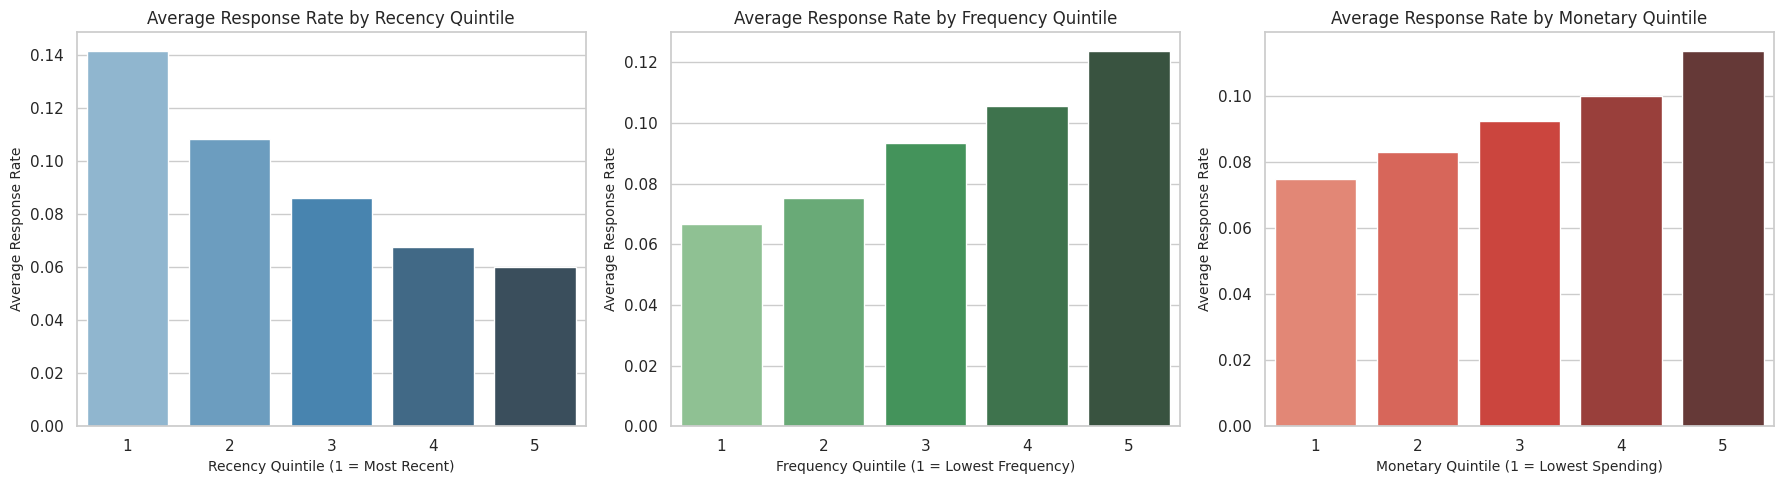

'\nInterpretation:\n- Recency: Customers who ordered more recently (lower recency values) typically show higher response rates.\n- Frequency: Customers with more frequent past orders tend to respond more positively to promotions.\n- Monetary: Higher-spending customers are generally more responsive to promotional offers.\nFrom a managerial perspective, targeting recent, frequent, and high-spending customers is likely to yield higher ROI.\n'

In [ ]:
# Question 2 — RFM Quintiles and Response Rate Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---
df.columns = df.columns.str.strip().str.lower()  # normalize column names
df['response'] = pd.to_numeric(df['response'], errors='coerce').fillna(0).astype(int)

# --- Create quintiles (1–5) ---
# Using rank to ensure exactly 5 bins even when duplicate values exist
df['recency_quintile'] = pd.qcut(df['recency'].rank(method='first'), 5, labels=False) + 1
df['frequency_quintile'] = pd.qcut(df['frequency'].rank(method='first'), 5, labels=False) + 1
df['monetary_quintile'] = pd.qcut(df['monetary'].rank(method='first'), 5, labels=False) + 1

# --- Compute average response rate by quintile ---
recency_avg = df.groupby('recency_quintile')['response'].mean()
frequency_avg = df.groupby('frequency_quintile')['response'].mean()
monetary_avg = df.groupby('monetary_quintile')['response'].mean()

# --- Plot bar charts ---
sns.set(style="whitegrid", palette="deep")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency plot
sns.barplot(x=recency_avg.index, y=recency_avg.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Average Response Rate by Recency Quintile", fontsize=12)
axes[0].set_xlabel("Recency Quintile (1 = Most Recent)", fontsize=10)
axes[0].set_ylabel("Average Response Rate", fontsize=10)

# Frequency plot
sns.barplot(x=frequency_avg.index, y=frequency_avg.values, ax=axes[1], palette="Greens_d")
axes[1].set_title("Average Response Rate by Frequency Quintile", fontsize=12)
axes[1].set_xlabel("Frequency Quintile (1 = Lowest Frequency)", fontsize=10)
axes[1].set_ylabel("Average Response Rate", fontsize=10)

# Monetary plot
sns.barplot(x=monetary_avg.index, y=monetary_avg.values, ax=axes[2], palette="Reds_d")
axes[2].set_title("Average Response Rate by Monetary Quintile", fontsize=12)
axes[2].set_xlabel("Monetary Quintile (1 = Lowest Spending)", fontsize=10)
axes[2].set_ylabel("Average Response Rate", fontsize=10)

plt.tight_layout()
plt.show()

# --- Managerial Interpretation (for reference in your report) ---
"""
Interpretation:
- Recency: Customers who ordered more recently (lower recency values) typically show higher response rates.
- Frequency: Customers with more frequent past orders tend to respond more positively to promotions.
- Monetary: Higher-spending customers are generally more responsive to promotional offers.
From a managerial perspective, targeting recent, frequent, and high-spending customers is likely to yield higher ROI.
"""

In [ ]:
# Question 3

# Given marginal cost of push notification
marginal_cost = 0.96

# Breakeven response rate
breakeven_response = marginal_cost / avg_profit_responders

print(f"Breakeven Response Rate: {breakeven_response:.4f} ({breakeven_response*100:.2f}%)")

Breakeven Response Rate: 0.0970 (9.70%)


In [ ]:
# Question 4

# Scenario: send to everyone (remaining 36,930,000 customers)
total_customers = 36_930_000

expected_responders = response_rate * total_customers
total_profit = expected_responders * avg_profit_responders
marketing_cost = total_customers * marginal_cost
projected_profit = total_profit - marketing_cost
ROMI = projected_profit / marketing_cost

print("Send to Everyone:")
print(f"Expected responders: {expected_responders:,.0f}")
print(f"Total projected profit: ${total_profit:,.2f}")
print(f"Marketing spend: ${marketing_cost:,.2f}")
print(f"Net projected profit: ${projected_profit:,.2f}")
print(f"Return on Marketing Investment (ROMI): {ROMI:.2f}")

Send to Everyone:
Expected responders: 3,430,269
Total projected profit: $33,955,969.07
Marketing spend: $35,452,800.00
Net projected profit: $-1,496,830.93
Return on Marketing Investment (ROMI): -0.04


In [ ]:
# Question 5

# Ensure required quintile columns exist
if "recency_quintile" not in df.columns:
    df["recency_quintile"] = pd.qcut(df["recency"], 5, labels=False, duplicates="drop") + 1
if "frequency_quintile" not in df.columns:
    df["frequency_quintile"] = pd.qcut(df["frequency"], 5, labels=False, duplicates="drop") + 1
if "monetary_quintile" not in df.columns:
    df["monetary_quintile"] = pd.qcut(df["monetary"], 5, labels=False, duplicates="drop") + 1

# Create RFM index (concatenate quintiles)
df["RFM_index"] = (
    df["recency_quintile"].astype(str)
    + df["frequency_quintile"].astype(str)
    + df["monetary_quintile"].astype(str)
)

# Compute average response rate by RFM index
rfm_response = df.groupby("RFM_index")["response"].mean().reset_index()

# Identify profitable RFM segments (above breakeven)
profitable_segments = rfm_response[rfm_response["response"] > breakeven_response]

# Number of customers per RFM segment (as proportion of total)
rfm_counts = df["RFM_index"].value_counts(normalize=True).reset_index()
rfm_counts.columns = ["RFM_index", "share"]

# Merge with profitable segments
target_segments = profitable_segments.merge(rfm_counts, on="RFM_index", how="left")

# A) Number of targeted customers
target_share = target_segments["share"].sum()
target_customers = total_customers * target_share

# B) Expected responders
avg_response_targeted = np.average(
    target_segments["response"], weights=target_segments["share"]
)
expected_responders_targeted = target_customers * avg_response_targeted

# C) Profit and ROMI
total_profit_targeted = expected_responders_targeted * avg_profit_responders
marketing_cost_targeted = target_customers * marginal_cost
projected_profit_targeted = total_profit_targeted - marketing_cost_targeted
ROMI_targeted = projected_profit_targeted / marketing_cost_targeted

print("RFM-Based Targeting:")
print(f"A) Targeted customers: {target_customers:,.0f}")
print(f"B) Expected responders: {expected_responders_targeted:,.0f}")
print(f"C) Projected total profit: ${total_profit_targeted:,.2f}")
print(f"   Marketing spend: ${marketing_cost_targeted:,.2f}")
print(f"   Net projected profit: ${projected_profit_targeted:,.2f}")
print(f"   ROMI (Return on Marketing): {ROMI_targeted:.2f}")

RFM-Based Targeting:
A) Targeted customers: 15,679,950
B) Expected responders: 2,015,323
C) Projected total profit: $19,949,523.51
   Marketing spend: $15,052,752.41
   Net projected profit: $4,896,771.09
   ROMI (Return on Marketing): 0.33
